# 04B · Modelado de siniestros con víctimas
### Entrenamiento y validación temporal expansiva

Este notebook entrena Regresión Logística, Random Forest y XGBoost sobre el escenario comparable de siniestros `Con Heridos` o `Con Muertos`. Los artefactos se guardan en `models/victimas/` y no reemplazan los modelos del escenario original.

## Diseño de la evaluación

La selección se realiza exclusivamente dentro de 2018–2022 mediante tres cortes: 2018–2019 → 2020, 2018–2020 → 2021 y 2018–2021 → 2022. En cada corte se recalculan el percentil 66 de la etiqueta, el preprocesamiento y el balance de clases. Average Precision es la métrica principal. Después se selecciona un umbral candidato con las predicciones fuera de muestra de 2020–2022.

## 1. Importación y configuración

In [1]:
from pathlib import Path
import json
import platform

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, brier_score_loss,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
DATA_FILE = Path('../data/processed/dataset_victimas_localidad_franja_fecha.parquet')
MODELS_PATH = Path('../models/victimas')
REPORTS_PATH = Path('../reports/modeling_victimas')
MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

## 2. Carga y variables

In [2]:
dataset = pd.read_parquet(DATA_FILE)
dataset['Fecha_Acc'] = pd.to_datetime(dataset['Fecha_Acc'])
cat_cols = ['Localidad', 'Franja_Horaria', 'Dia_Semana']
num_cols = [
    'Mes', 'Es_Fin_de_Semana', 'Es_Festivo',
    'Accidentes_Prom_7d', 'Accidentes_Prom_30d', 'Accidentes_Semana_Anterior',
    'Sin_Historial_Accidentes_Prom_7d', 'Sin_Historial_Accidentes_Prom_30d',
    'Sin_Historial_Accidentes_Semana_Anterior'
]
feature_cols = cat_cols + num_cols
required = feature_cols + ['Fecha_Acc', 'Num_Accidentes', 'Periodo', 'Alto_Riesgo']
assert not set(required).difference(dataset.columns)
assert dataset[required].isna().sum().sum() == 0
print(f'Dataset: {dataset.shape[0]:,} filas, {dataset.shape[1]} columnas')
display(dataset.groupby('Periodo')['Alto_Riesgo'].agg(['count', 'sum', 'mean']))

Dataset: 204,560 filas, 16 columnas


,count,sum,mean
Periodo,,,
test,58480,11118,0.190116
train,146080,24907,0.170502


## 3. Funciones de etiqueta y evaluación

In [3]:
group_cols = ['Localidad', 'Franja_Horaria']

def apply_past_target(train_part, validation_part):
    thresholds = (train_part.groupby(group_cols, observed=True)['Num_Accidentes']
                  .quantile(2 / 3).rename('Umbral_Etiqueta').reset_index())
    train_labeled = train_part.merge(thresholds, on=group_cols, how='left', validate='many_to_one')
    val_labeled = validation_part.merge(thresholds, on=group_cols, how='left', validate='many_to_one')
    assert train_labeled.Umbral_Etiqueta.notna().all() and val_labeled.Umbral_Etiqueta.notna().all()
    y_train = (train_labeled.Num_Accidentes > train_labeled.Umbral_Etiqueta).astype(int)
    y_val = (val_labeled.Num_Accidentes > val_labeled.Umbral_Etiqueta).astype(int)
    return train_labeled, val_labeled, y_train, y_val

def metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'AUC_ROC': roc_auc_score(y_true, y_score),
        'Average_Precision': average_precision_score(y_true, y_score),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Especificidad': tn / (tn + fp),
        'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Brier': brier_score_loss(y_true, y_score),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

## 4. Constructores de modelos

In [4]:
def logistic_preprocessor():
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

def tree_preprocessor():
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ], remainder='passthrough')

def build_models(scale_pos_weight):
    return {
        'Regresión Logística': Pipeline([
            ('preprocesador', logistic_preprocessor()),
            ('modelo', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
        ]),
        'Random Forest': Pipeline([
            ('preprocesador', tree_preprocessor()),
            ('modelo', RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=20,
                                              class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        'XGBoost': Pipeline([
            ('preprocesador', tree_preprocessor()),
            ('modelo', xgb.XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight,
                                         random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1))
        ])
    }

## 5. Validación temporal expansiva

In [5]:
folds = [('2018-2019', 2019, 2020), ('2018-2020', 2020, 2021), ('2018-2021', 2021, 2022)]
validation_rows, oof_frames = [], []
for fold_id, (train_label, train_end, val_year) in enumerate(folds, 1):
    train_fold = dataset[dataset.Fecha_Acc.dt.year <= train_end].copy()
    val_fold = dataset[dataset.Fecha_Acc.dt.year == val_year].copy()
    train_fold, val_fold, y_train, y_val = apply_past_target(train_fold, val_fold)
    X_train, X_val = train_fold[feature_cols], val_fold[feature_cols]
    scale = (y_train == 0).sum() / (y_train == 1).sum()
    print(f'Corte {fold_id}: {train_label} → {val_year}; prevalencia {y_train.mean():.2%} → {y_val.mean():.2%}')
    for name, pipeline in build_models(scale).items():
        pipeline.fit(X_train, y_train)
        score = pipeline.predict_proba(X_val)[:, 1]
        pred = (score >= 0.5).astype(int)
        validation_rows.append({
            'Corte': fold_id, 'Entrenamiento': train_label, 'Anio_Validacion': val_year,
            'Modelo': name, 'N_Train': len(train_fold), 'N_Validacion': len(val_fold),
            'Prevalencia_Train': y_train.mean(), 'Prevalencia_Validacion': y_val.mean(),
            **metrics(y_val, pred, score)})
        oof_frames.append(pd.DataFrame({
            'Corte': fold_id, 'Anio_Validacion': val_year, 'Modelo': name,
            'Fecha_Acc': val_fold.Fecha_Acc.to_numpy(), 'Localidad': val_fold.Localidad.to_numpy(),
            'Franja_Horaria': val_fold.Franja_Horaria.to_numpy(),
            'Umbral_Etiqueta': val_fold.Umbral_Etiqueta.to_numpy(), 'Alto_Riesgo': y_val.to_numpy(),
            'Probabilidad': score, 'Prediccion_05': pred}))
validation_metrics = pd.DataFrame(validation_rows)
oof_predictions = pd.concat(oof_frames, ignore_index=True)
print('Validación terminada.')

Corte 1: 2018-2019 → 2020; prevalencia 15.89% → 10.27%


Corte 2: 2018-2020 → 2021; prevalencia 15.97% → 15.81%


Corte 3: 2018-2021 → 2022; prevalencia 16.58% → 18.95%


Validación terminada.


## 6. Comparación y selección

In [6]:
metric_cols = ['F1', 'AUC_ROC', 'Average_Precision', 'Precision', 'Recall', 'Brier']
validation_summary = (validation_metrics.groupby('Modelo')[metric_cols]
                      .agg(['mean', 'std'])
                      .sort_values(('Average_Precision', 'mean'), ascending=False))
selected_model_name = validation_summary.index[0]
validation_metrics.to_csv(REPORTS_PATH / 'validacion_temporal_detalle.csv', index=False, encoding='utf-8-sig')
validation_summary.to_csv(REPORTS_PATH / 'validacion_temporal_resumen.csv', encoding='utf-8-sig')
oof_predictions.to_parquet(REPORTS_PATH / 'predicciones_oof_2020_2022.parquet', index=False)
display(validation_metrics[['Entrenamiento', 'Anio_Validacion', 'Modelo',
                            'Prevalencia_Validacion', *metric_cols]].round(4))
display(validation_summary.round(4))
print('Modelo seleccionado:', selected_model_name)

,Entrenamiento,Anio_Validacion,Modelo,Prevalencia_Validacion,F1,AUC_ROC,Average_Precision,Precision,Recall,Brier
0,2018-2019,2020,Regresión Logística,0.1027,0.2318,0.6414,0.1477,0.1376,0.7340,0.2434
1,2018-2019,2020,Random Forest,0.1027,0.2499,0.6812,0.1754,0.1515,0.7141,0.2233
2,2018-2019,2020,XGBoost,0.1027,0.2508,0.6544,0.1561,0.1571,0.6217,0.2245
3,2018-2020,2021,Regresión Logística,0.1581,0.3251,0.6572,0.2463,0.2123,0.6944,0.2337
4,2018-2020,2021,Random Forest,0.1581,0.3465,0.6914,0.2709,0.2250,0.7535,0.2265
5,2018-2020,2021,XGBoost,0.1581,0.3513,0.6814,0.2567,0.2427,0.6359,0.2165
6,2018-2021,2022,Regresión Logística,0.1895,0.3572,0.6356,0.2716,0.2414,0.6868,0.2392
7,2018-2021,2022,Random Forest,0.1895,0.3914,0.6854,0.3015,0.2612,0.7800,0.2311
8,2018-2021,2022,XGBoost,0.1895,0.3949,0.6799,0.2952,0.2810,0.6642,0.2223


F1         AUC_ROC         Average_Precision          \
                       mean     std    mean     std              mean     std   
Modelo                                                                          
Random Forest        0.3293  0.0723  0.6860  0.0051            0.2493  0.0658   
XGBoost              0.3323  0.0739  0.6719  0.0152            0.2360  0.0718   
Regresión Logística  0.3047  0.0651  0.6447  0.0112            0.2219  0.0655   

                    Precision          Recall           Brier          
                         mean     std    mean     std    mean     std  
Modelo                                                                 
Random Forest          0.2126  0.0559  0.7492  0.0332  0.2269  0.0039  
XGBoost                0.2269  0.0634  0.6406  0.0216  0.2211  0.0041  
Regresión Logística    0.1971  0.0535  0.7051  0.0254  0.2388  0.0049

Modelo seleccionado: Random Forest


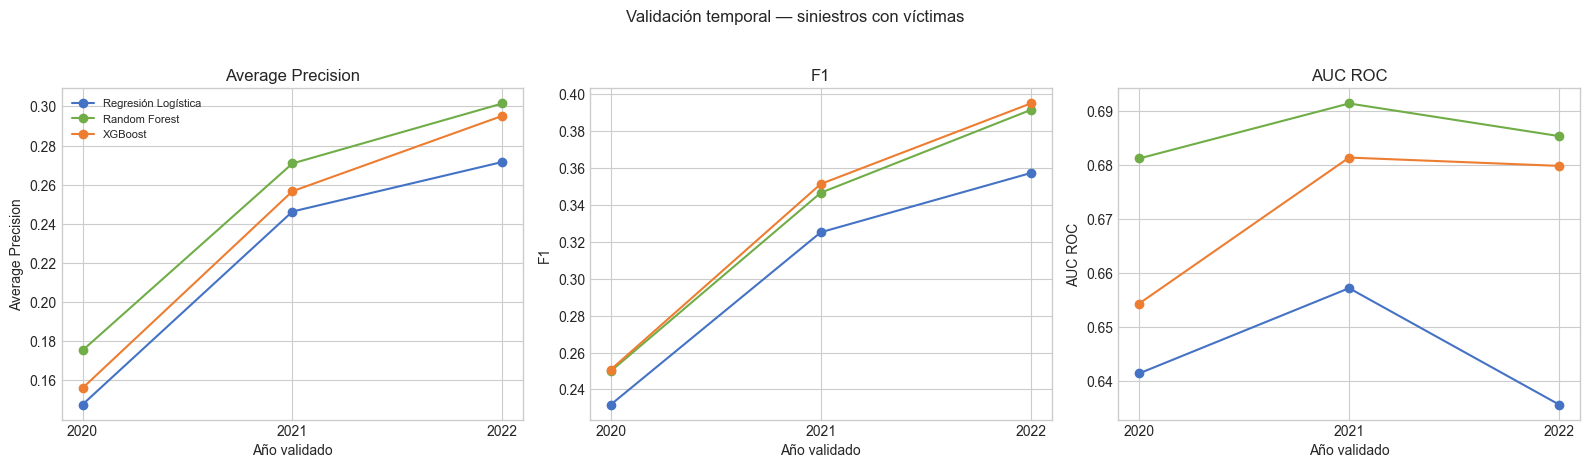

In [7]:
colors = {'Regresión Logística': '#4472C4', 'Random Forest': '#70AD47', 'XGBoost': '#ED7D31'}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ['Average_Precision', 'F1', 'AUC_ROC']):
    pivot = validation_metrics.pivot(index='Anio_Validacion', columns='Modelo', values=metric)
    pivot[list(colors)].plot(marker='o', ax=ax, color=list(colors.values()))
    ax.set(title=metric.replace('_', ' '), xlabel='Año validado', ylabel=metric.replace('_', ' '))
    ax.set_xticks([2020, 2021, 2022])
    if ax is not axes[0]: ax.get_legend().remove()
axes[0].legend(fontsize=8)
plt.suptitle('Validación temporal — siniestros con víctimas', y=1.03)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '01_validacion_temporal_modelos.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Selección del umbral con predicciones 2020–2022

In [8]:
selected_oof = oof_predictions[oof_predictions.Modelo.eq(selected_model_name)].copy()
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 181):
    pred = (selected_oof.Probabilidad.to_numpy() >= threshold).astype(int)
    threshold_rows.append({'Umbral': threshold, **metrics(selected_oof.Alto_Riesgo, pred, selected_oof.Probabilidad)})
threshold_table = pd.DataFrame(threshold_rows)
candidate_threshold = float(threshold_table.loc[threshold_table.F1.idxmax(), 'Umbral'])
threshold_table.to_csv(REPORTS_PATH / 'seleccion_umbral_2020_2022.csv', index=False, encoding='utf-8-sig')
default_row = threshold_table.iloc[(threshold_table.Umbral - 0.5).abs().argmin()]
candidate_row = threshold_table.loc[threshold_table.Umbral.eq(candidate_threshold)].iloc[0]
print(f'Umbral candidato para {selected_model_name}: {candidate_threshold:.3f}')
display(pd.DataFrame({'Umbral 0.5': default_row, f'Umbral {candidate_threshold:.3f}': candidate_row}).T
        [['F1', 'Precision', 'Recall', 'Especificidad', 'FP', 'FN', 'TP', 'TN']].round(4))

Umbral candidato para Random Forest: 0.550


,F1,Precision,Recall,Especificidad,FP,FN,TP,TN
Umbral 0.5,0.3352,0.2154,0.7557,0.5140,36221.0,3215.0,9943.0,38301.0
Umbral 0.550,0.3547,0.2563,0.5762,0.7047,22003.0,5577.0,7581.0,52519.0


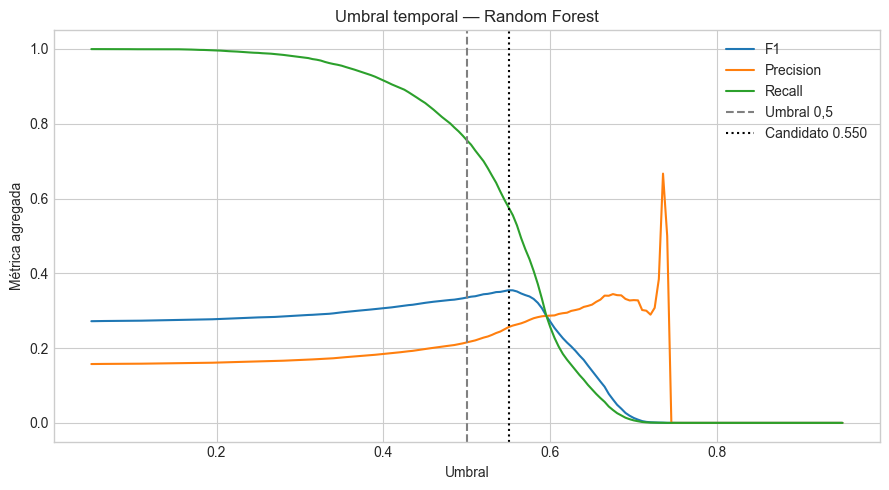

In [9]:
plt.figure(figsize=(9, 5))
for metric in ['F1', 'Precision', 'Recall']:
    plt.plot(threshold_table.Umbral, threshold_table[metric], label=metric)
plt.axvline(0.5, linestyle='--', color='gray', label='Umbral 0,5')
plt.axvline(candidate_threshold, linestyle=':', color='black', label=f'Candidato {candidate_threshold:.3f}')
plt.xlabel('Umbral'); plt.ylabel('Métrica agregada'); plt.title(f'Umbral temporal — {selected_model_name}')
plt.legend(); plt.tight_layout()
plt.savefig(REPORTS_PATH / '02_seleccion_umbral.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Entrenamiento final con 2018–2022

In [10]:
train_final = dataset[dataset.Periodo.eq('train')].copy()
X_train_final = train_final[feature_cols]
y_train_final = train_final.Alto_Riesgo.astype(int)
scale_final = (y_train_final == 0).sum() / (y_train_final == 1).sum()
final_pipelines = build_models(scale_final)
for name, pipeline in final_pipelines.items():
    print('Entrenando:', name)
    pipeline.fit(X_train_final, y_train_final)
print('Modelos finales ajustados con 2018–2022.')

Entrenando: Regresión Logística


Entrenando: Random Forest


Entrenando: XGBoost


Modelos finales ajustados con 2018–2022.


## 9. Confirmación retrospectiva 2023–2024

In [11]:
test = dataset[dataset.Periodo.eq('test')].copy()
X_test, y_test = test[feature_cols], test.Alto_Riesgo.astype(int)
test_rows, test_prediction_frames = [], []
for name, pipeline in final_pipelines.items():
    score = pipeline.predict_proba(X_test)[:, 1]
    threshold = candidate_threshold if name == selected_model_name else 0.5
    pred = (score >= threshold).astype(int)
    test_rows.append({'Modelo': name, 'Umbral': threshold, **metrics(y_test, pred, score)})
    test_prediction_frames.append(pd.DataFrame({
        'Fecha_Acc': test.Fecha_Acc.to_numpy(), 'Localidad': test.Localidad.to_numpy(),
        'Franja_Horaria': test.Franja_Horaria.to_numpy(), 'Alto_Riesgo': y_test.to_numpy(),
        'Modelo': name, 'Umbral': threshold, 'Probabilidad': score, 'Prediccion': pred}))
test_metrics = pd.DataFrame(test_rows).sort_values('Average_Precision', ascending=False)
test_predictions = pd.concat(test_prediction_frames, ignore_index=True)
test_metrics.to_csv(REPORTS_PATH / 'confirmacion_retrospectiva_2023_2024.csv', index=False, encoding='utf-8-sig')
test_predictions.to_parquet(REPORTS_PATH / 'predicciones_2023_2024.parquet', index=False)
test_metrics.round(4)

,Modelo,Umbral,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,TN,FP,FN,TP
1,Random Forest,0.55,0.3982,0.6853,0.3038,0.3011,0.5877,0.6797,0.6337,0.2304,32194,15168,4584,6534
2,XGBoost,0.50,0.3937,0.6800,0.3020,0.2793,0.6670,0.5960,0.6315,0.2228,28226,19136,3702,7416
0,Regresión Logística,0.50,0.3633,0.6411,0.2702,0.2452,0.7004,0.4940,0.5972,0.2383,23395,23967,3331,7787


2023–2024 se utiliza como confirmación retrospectiva. Aunque no participa en la selección realizada por este notebook, ya fue inspeccionado durante etapas anteriores del proyecto y no debe presentarse como una prueba completamente intacta.

## 10. Guardado de artefactos

In [12]:
file_names = {
    'Regresión Logística': 'pipeline_logistica_victimas.pkl',
    'Random Forest': 'pipeline_random_forest_victimas.pkl',
    'XGBoost': 'pipeline_xgboost_victimas.pkl'
}
for name, pipeline in final_pipelines.items():
    joblib.dump(pipeline, MODELS_PATH / file_names[name])

# Artefactos separados para compatibilidad con la estructura original.
joblib.dump(final_pipelines['Regresión Logística'].named_steps['modelo'], MODELS_PATH / 'modelo_logistica.pkl')
joblib.dump(final_pipelines['Regresión Logística'].named_steps['preprocesador'], MODELS_PATH / 'preprocesador_logistica.pkl')
joblib.dump(final_pipelines['Random Forest'].named_steps['modelo'], MODELS_PATH / 'modelo_random_forest.pkl')
joblib.dump(final_pipelines['XGBoost'].named_steps['modelo'], MODELS_PATH / 'modelo_xgboost.pkl')
joblib.dump(final_pipelines['Random Forest'].named_steps['preprocesador'], MODELS_PATH / 'preprocesador_arboles.pkl')
joblib.dump(final_pipelines[selected_model_name], MODELS_PATH / 'pipeline_modelo_seleccionado.pkl')

metadata = {
    'universo': 'Siniestros Con Heridos o Con Muertos',
    'dataset': str(DATA_FILE),
    'entrenamiento': '2018-01-01 a 2022-12-31',
    'confirmacion_retrospectiva': '2023-01-01 a 2024-12-31',
    'modelo_seleccionado': selected_model_name,
    'criterio_seleccion': 'Mayor Average Precision promedio en validacion temporal expansiva',
    'umbral_candidato': candidate_threshold,
    'variables': feature_cols,
    'random_state': RANDOM_STATE,
    'version_python': platform.python_version(),
    'version_pandas': pd.__version__,
    'version_sklearn': sklearn.__version__,
    'version_xgboost': xgb.__version__
}
(MODELS_PATH / 'metadata_modelo.json').write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8')
print('Artefactos guardados en:', MODELS_PATH.resolve())
for path in sorted(MODELS_PATH.iterdir()): print('-', path.name)

Artefactos guardados en: /Users/camilo/Library/CloudStorage/OneDrive-FundaciónUniversitariaKonradLorenz/Siniestralidad_Vial/reports/reproducibilidad/ejecucion_20260913/models/victimas
- metadata_modelo.json
- modelo_logistica.pkl
- modelo_random_forest.pkl
- modelo_xgboost.pkl
- pipeline_logistica_victimas.pkl
- pipeline_modelo_seleccionado.pkl
- pipeline_random_forest_victimas.pkl
- pipeline_xgboost_victimas.pkl
- preprocesador_arboles.pkl
- preprocesador_logistica.pkl


## Conclusión del modelado

Random Forest obtiene la mayor Average Precision promedio en la validación temporal: 0,2493, frente a 0,2360 de XGBoost y 0,2219 de Regresión Logística. El umbral candidato 0,55, seleccionado exclusivamente con predicciones fuera de muestra de 2020–2022, eleva el F1 agregado de Random Forest de 0,3352 a 0,3547, aumentando la precisión y reduciendo el recall.

En la confirmación retrospectiva 2023–2024, Random Forest alcanza F1=0,3982, AUC-ROC=0,6853, Average Precision=0,3038, precisión=30,11 % y recall=58,77 %. XGBoost obtiene resultados cercanos: F1=0,3937 y Average Precision=0,3020. La diferencia es pequeña y no demuestra superioridad estadística, pero Random Forest se conserva como selección reproducible bajo el criterio definido. El umbral requiere todavía una decisión operativa sobre el costo de falsas alertas y omisiones antes de incorporarse al dashboard.